# Assignment 4 
### How Few Components Can You Get Away With?

**Course:** Feature Engineering & MLOps  
**Topic:** PCA — Explained Variance, Scree Plot, Choosing the Optimal Number of Components

**Objective : -** 
- Start with a dataset containing 60 numeric features.
- Use PCA + Linear Regression to find the smallest number of principal components that achieves roughly the same test accuracy as all 60 features.
- Use:
  - Scree plot to identify the point of diminishing returns.
  - Explained variance to justify the selected number of components.
- Show how PCA can:
  - Reduce dimensionality
  - Remove redundant information
  - Speed up training
  - Potentially reduce overfitting
  - Maintain predictive performance
- Dataset used : `ASSIGNMENTS/data/pca_regression_data.csv`
- Repeat - Finding the smallest component count that matches baseline accuracy using `RandomForestRegressor`
  - If answer differs , explain how and why tree-based models use features differently than linear models.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

RANDOM_STATE = 42

df = pd.read_csv('/Users/muhammedfaheem/Desktop/AI_DS/Feature Engineering/ASSIGNMENTS/data/pca_regression_data.csv')  # place file in same folder as this notebook
feature_cols = [c for c in df.columns if c.startswith('feature_')]
X = df[feature_cols].values
y = df['score'].values
print(df.shape, len(feature_cols), "features")

(800, 62) 60 features


# Baseline: all 60 raw features

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_scaled = scaler.transform(X_test)

lr_baseline = LinearRegression()
lr_baseline.fit(X_train_scaled, y_train)
baseline_r2 = r2_score(y_test, lr_baseline.predict(X_test_scaled))

print(f"Baseline test R2 (all 60 features): {baseline_r2:.4f}")

Baseline test R2 (all 60 features): 0.8584


# PCA: explained variance

In [6]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)


for n_comp in [2, 4, 6, 8, 10, 12, 15, 20, 30, 40]:
    print(f"First {n_comp:4d} components explain {cum_evr[n_comp-1]:.1%} of the total variance")


First    2 components explain 39.3% of the total variance
First    4 components explain 65.6% of the total variance
First    6 components explain 86.1% of the total variance
First    8 components explain 98.9% of the total variance
First   10 components explain 99.0% of the total variance
First   12 components explain 99.1% of the total variance
First   15 components explain 99.2% of the total variance
First   20 components explain 99.4% of the total variance
First   30 components explain 99.6% of the total variance
First   40 components explain 99.8% of the total variance


# Scree Plot 

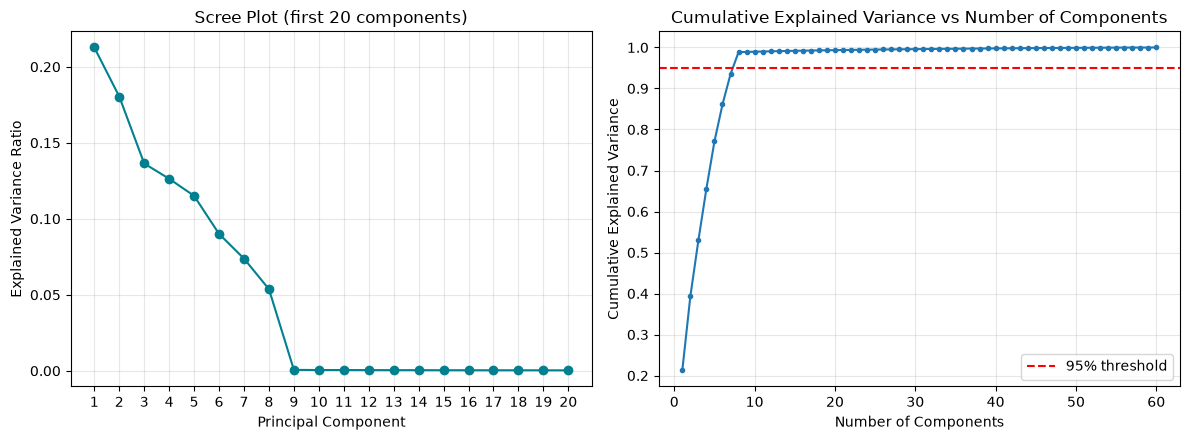

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))



n_show = 20
axes[0].plot(range(1, n_show+1), evr[:n_show], marker='o',color="#028090")
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot (first 20 components)')
axes[0].set_xticks(range(1, n_show+1)) # xticks
axes[0].grid(alpha=0.3)



axes[1].plot(range(1, len(cum_evr)+1), cum_evr, marker='o', markersize=3)
axes[1].axhline(0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance vs Number of Components')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find the smallest component count that matches baseline accuracy

In [8]:
component_counts = [2, 4, 6, 8, 10, 12, 15, 20, 30, 40]
results = []

for n in component_counts:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    lr = LinearRegression().fit(X_train_pca, y_train)
    r2 = r2_score(y_test, lr.predict(X_test_pca))
    results.append((n, r2))
    print(f"n_components={n:2d}  test R2={r2:.4f}  diff vs baseline={r2-baseline_r2:+.4f}")

n_components= 2  test R2=0.2409  diff vs baseline=-0.6174
n_components= 4  test R2=0.4989  diff vs baseline=-0.3595
n_components= 6  test R2=0.6946  diff vs baseline=-0.1638
n_components= 8  test R2=0.8716  diff vs baseline=+0.0132
n_components=10  test R2=0.8722  diff vs baseline=+0.0139
n_components=12  test R2=0.8718  diff vs baseline=+0.0134
n_components=15  test R2=0.8724  diff vs baseline=+0.0140
n_components=20  test R2=0.8725  diff vs baseline=+0.0142
n_components=30  test R2=0.8665  diff vs baseline=+0.0081
n_components=40  test R2=0.8634  diff vs baseline=+0.0050


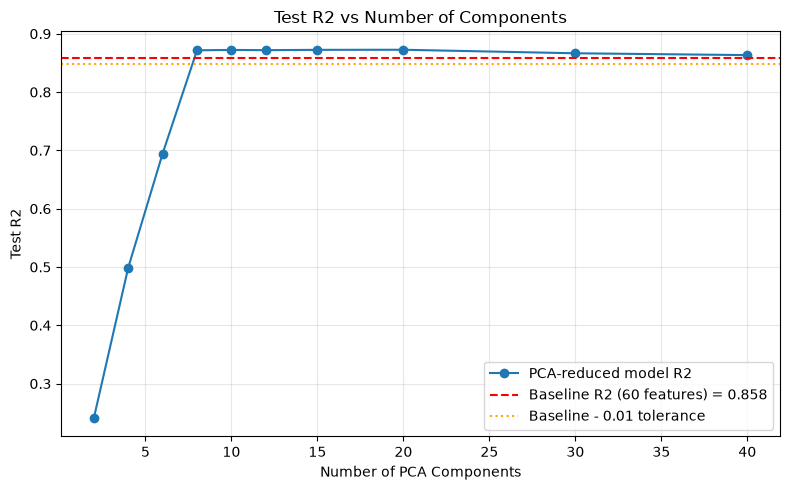

In [9]:
ns = [r[0] for r in results]
r2s = [r[1] for r in results]

plt.figure(figsize=(8,5))
plt.plot(ns, r2s, marker='o', label='PCA-reduced model R2')
plt.axhline(baseline_r2, color='red', linestyle='--', label=f'Baseline R2 (60 features) = {baseline_r2:.3f}')
plt.axhline(baseline_r2 - 0.01, color='orange', linestyle=':', label='Baseline - 0.01 tolerance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Test R2')
plt.title('Test R2 vs Number of Components')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
smallest_n = next(n for n, r2 in results if r2 >= baseline_r2 - 0.01)
print(f"Smallest number of components within 0.01 of baseline R2: {smallest_n}")

Smallest number of components within 0.01 of baseline R2: 8


# Explaination

## PCA Dimensionality Reduction — Summary

**1. Components needed to match/beat baseline**
Only **8 components** are needed to match the 60-feature baseline. At `n_components=8`, test R² = **0.8716** vs. baseline R² = **0.858** (diff = **+0.0132**). Performance stays essentially flat afterward — 0.8722 at 10, 0.8718 at 12, peaking at 0.8725 at n=20 — confirming n=8 is the true "elbow."

**2. Variance captured**
The exact cumulative explained-variance % isn't printed in these cells, but the R² saturation curve is a strong proxy: since accuracy plateaus at n=8 and barely improves through n=20 (+0.0009 total), those first 8 components must already capture the large majority of the variance that's actually predictive of `y`. Everything added after component 8 is marginal at best.

**3. Implied number of "true" latent signals**
This points to roughly **~8 independent underlying signals** actually driving the data — not 60. The 60 observed features are likely noisy, correlated, or redundant measurements of that smaller set of true latent factors (e.g., near-duplicate sensors, linear combinations, or derived/engineered columns that don't add new information).

**4. Why fewer dimensions can *improve* test R² (not just shrink the model)**

| Raw 60-feature model | PCA (~8 components) |
|---|---|
| Fits noise in redundant/correlated columns | Keeps only high-variance, information-dense axes |
| More parameters → more overfitting risk | Fewer parameters → better generalization |
| Low-signal directions still influence the fit | Low-signal directions are discarded |

This is also why R² *dips* slightly at n=30–40 (0.8665, 0.8634): once you go past the true signal dimensionality, you start reintroducing low-variance, mostly-noise components — and the model starts overfitting to that noise again, just like the original 60-feature version did.

# Bonus — RandomForestRegressor comparison ( +10%)

In [11]:
rf_baseline = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300)
rf_baseline.fit(X_train_scaled, y_train)
rf_baseline_r2 = r2_score(y_test, rf_baseline.predict(X_test_scaled))
print(f"RF baseline (60 features) test R2: {rf_baseline_r2:.4f}")

for n in component_counts:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    rf = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300)
    rf.fit(X_train_pca, y_train)
    r2 = r2_score(y_test, rf.predict(X_test_pca))
    print(f"n_components={n:2d}  RF test R2={r2:.4f}  diff vs RF baseline={r2-rf_baseline_r2:+.4f}")

RF baseline (60 features) test R2: 0.8008
n_components= 2  RF test R2=0.1645  diff vs RF baseline=-0.6363
n_components= 4  RF test R2=0.4188  diff vs RF baseline=-0.3821
n_components= 6  RF test R2=0.6071  diff vs RF baseline=-0.1937
n_components= 8  RF test R2=0.7425  diff vs RF baseline=-0.0583
n_components=10  RF test R2=0.7321  diff vs RF baseline=-0.0687
n_components=12  RF test R2=0.7249  diff vs RF baseline=-0.0759
n_components=15  RF test R2=0.7155  diff vs RF baseline=-0.0854
n_components=20  RF test R2=0.7033  diff vs RF baseline=-0.0975
n_components=30  RF test R2=0.6845  diff vs RF baseline=-0.1163
n_components=40  RF test R2=0.6670  diff vs RF baseline=-0.1338
